# exploratory data analysis

looking at the master table to understand what the data looks like before doing any tests.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('cleaned/master.csv', parse_dates=['purchase_date', 'order_purchase_timestamp'])

print('shape:', df.shape)
df.head(3)

shape: (88675, 23)


,order_id,customer_id,order_status,order_purchase_timestamp,purchase_date,purchase_hour,is_returned,customer_zip_code_prefix,customer_state,lat,...,temp_max_c,temp_min_c,precip_total_mm,humidity_mean,item_count,total_price,total_freight,total_payment_value,payment_type,main_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02,10,0,3149,SP,-23.576983,...,22.7,16.8,16.8,63.958333,1.0,29.99,8.72,38.71,voucher,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-24,20,0,47813,BA,-12.177924,...,31.2,13.8,0.0,56.166667,1.0,118.70,22.76,141.46,boleto,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08,8,0,75265,GO,-16.745150,...,30.7,15.5,0.0,56.416667,1.0,159.90,19.22,179.12,credit_card,auto


## basic overview

just a quick look at the numbers to make sure everything makes sense

In [2]:
print('date range:', df['purchase_date'].min(), 'to', df['purchase_date'].max())
print('total orders:', len(df))
print('cancelled/unavailable orders:', df['is_returned'].sum())
print('cancellation rate:', round(df['is_returned'].mean() * 100, 2), '%')
print()
print('order status breakdown:')
print(df['order_status'].value_counts())

date range: 2016-09-04 00:00:00 to 2018-09-03 00:00:00
total orders: 88675
cancelled/unavailable orders: 407
cancellation rate: 0.46 %

order status breakdown:
order_status
delivered      86732
shipped          987
canceled         401
invoiced         283
processing       264
unavailable        6
approved           2
Name: count, dtype: int64


In [3]:
# basic stats on the numeric columns
df[['total_price', 'temp_mean_c', 'precip_total_mm', 'humidity_mean']].describe()

,total_price,temp_mean_c,precip_total_mm,humidity_mean
count,88675.000000,88675.000000,88675.000000,88215.000000
mean,138.563999,21.515978,3.510847,72.735757
std,212.286450,3.856456,9.877395,12.044744
min,0.850000,-2.412500,0.000000,10.000000
25%,45.950000,19.154167,0.000000,66.250000
50%,86.990000,21.720833,0.000000,74.041667
75%,149.980000,24.225000,1.400000,81.208333
max,13440.000000,35.550000,182.000000,100.000000


## orders over time

we group by month and count how many orders there were each month.
this shows if there are seasonal patterns or if orders grew over time.

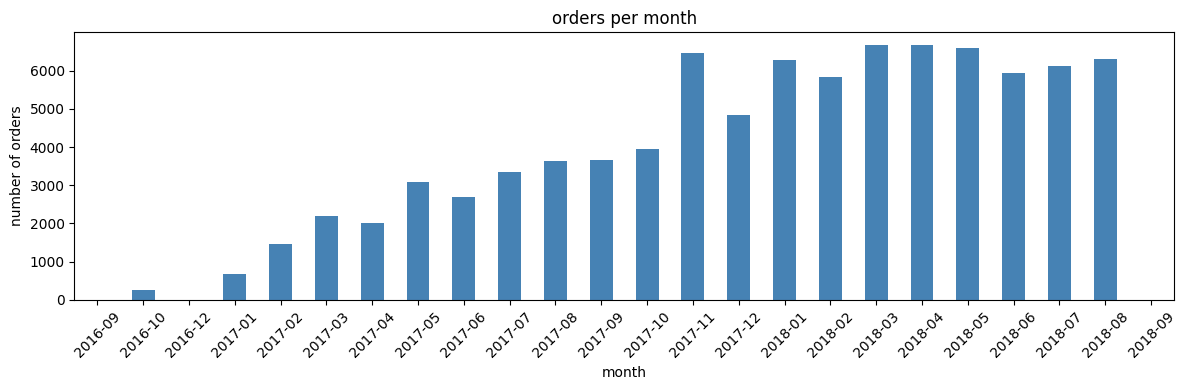

min: 1 | max: 6665


In [4]:
# group orders by month
df['year_month'] = df['purchase_date'].dt.to_period('M')
orders_per_month = df.groupby('year_month').size()

plt.figure(figsize=(12, 4))
orders_per_month.plot(kind='bar', color='steelblue')
plt.title('orders per month')
plt.xlabel('month')
plt.ylabel('number of orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('cleaned/plot_orders_per_month.png', dpi=100)
plt.show()
print('min:', orders_per_month.min(), '| max:', orders_per_month.max())

## order value distribution

we look at how much people typically spend per order.
we cut off at the 99th percentile to avoid the chart being stretched by a few extreme outliers.

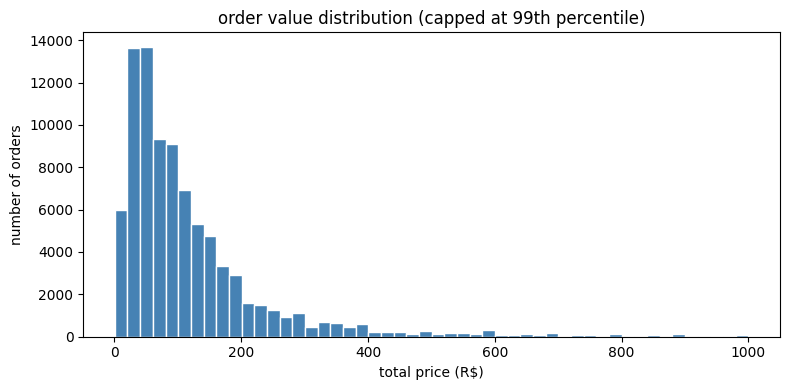

median spend: R$ 86.99
mean spend:   R$ 138.56
99th pct:     R$ 999.8


In [5]:
# cut off extreme outliers for the chart (top 1%)
cap = df['total_price'].quantile(0.99)
spend = df[df['total_price'] <= cap]['total_price']

plt.figure(figsize=(8, 4))
plt.hist(spend, bins=50, color='steelblue', edgecolor='white')
plt.title('order value distribution (capped at 99th percentile)')
plt.xlabel('total price (R$)')
plt.ylabel('number of orders')
plt.tight_layout()
plt.savefig('cleaned/plot_spend_distribution.png', dpi=100)
plt.show()

print('median spend: R$', round(df['total_price'].median(), 2))
print('mean spend:   R$', round(df['total_price'].mean(), 2))
print('99th pct:     R$', round(cap, 2))

## weather distributions

before we can test if weather affects purchases we need to understand the weather data itself.
what temperature range are we working with? how rainy is it typically?

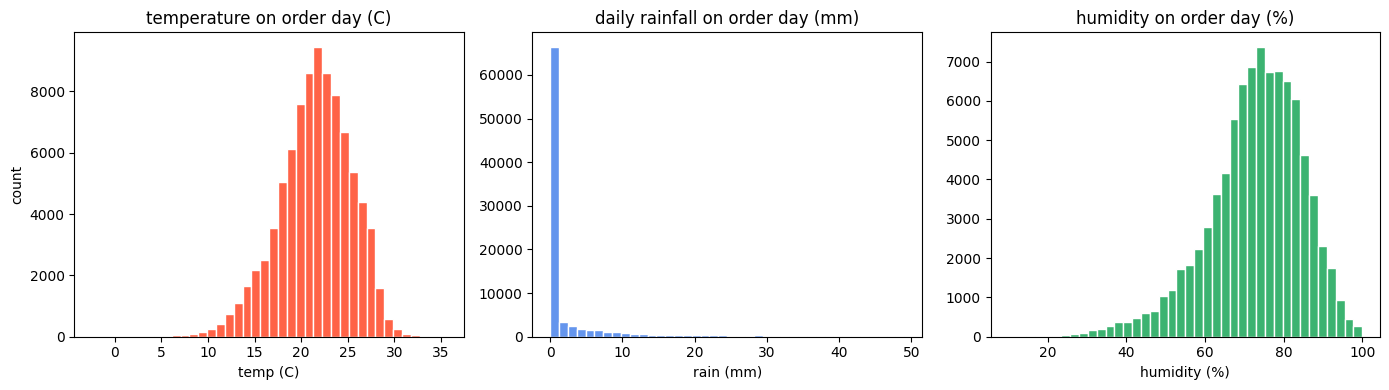

temp range:      -2.4 to 35.6 C
rain range:      0.0 to 182.0 mm
humidity range:  10.0 to 100.0 %


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# temperature
axes[0].hist(df['temp_mean_c'].dropna(), bins=40, color='tomato', edgecolor='white')
axes[0].set_title('temperature on order day (C)')
axes[0].set_xlabel('temp (C)')
axes[0].set_ylabel('count')

# rain - cap at 99th pct because there are some massive rain events
rain_cap = df['precip_total_mm'].quantile(0.99)
rain = df[df['precip_total_mm'] <= rain_cap]['precip_total_mm']
axes[1].hist(rain, bins=40, color='cornflowerblue', edgecolor='white')
axes[1].set_title('daily rainfall on order day (mm)')
axes[1].set_xlabel('rain (mm)')

# humidity
axes[2].hist(df['humidity_mean'].dropna(), bins=40, color='mediumseagreen', edgecolor='white')
axes[2].set_title('humidity on order day (%)')
axes[2].set_xlabel('humidity (%)')

plt.tight_layout()
plt.savefig('cleaned/plot_weather_distributions.png', dpi=100)
plt.show()

print('temp range:     ', round(df['temp_mean_c'].min(),1), 'to', round(df['temp_mean_c'].max(),1), 'C')
print('rain range:     ', round(df['precip_total_mm'].min(),1), 'to', round(df['precip_total_mm'].max(),1), 'mm')
print('humidity range: ', round(df['humidity_mean'].min(),1), 'to', round(df['humidity_mean'].max(),1), '%')

## order volume vs weather

we look at how many order per day and plot that against the weather on that day.
this gives a first visual hint of whether there is any relationship.

In [7]:
# count orders per day and get the average weather for that day across all stations
daily = df.groupby('purchase_date').agg(
    order_count     = ('order_id', 'count'),
    avg_temp        = ('temp_mean_c', 'mean'),
    total_rain      = ('precip_total_mm', 'mean'),
    avg_humidity    = ('humidity_mean', 'mean'),
    avg_spend       = ('total_price', 'mean')
).reset_index()

print(daily.shape)
daily.head(3)

(616, 6)


,purchase_date,order_count,avg_temp,total_rain,avg_humidity,avg_spend
0,2016-09-04,1,26.708333,1.0,71.916667,72.89
1,2016-09-05,1,14.275000,24.6,93.291667,59.50
2,2016-09-15,1,23.775000,0.0,46.541667,134.97


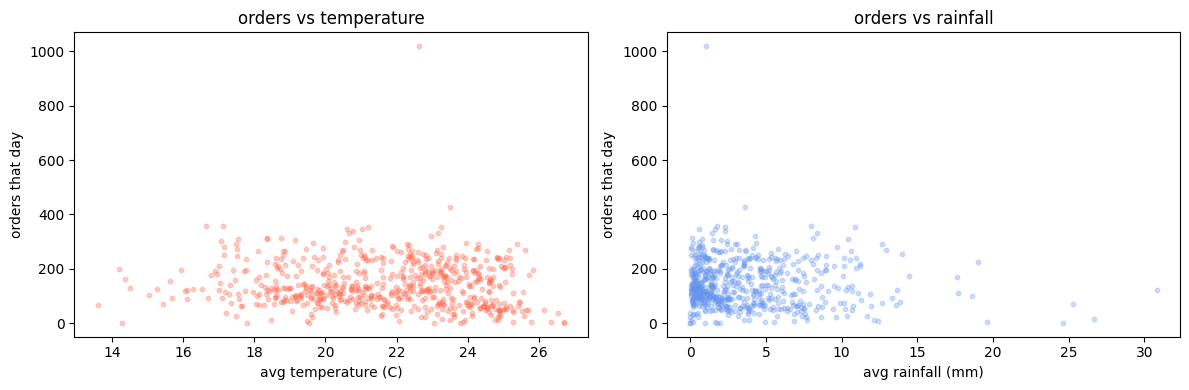

In [8]:
# scatter: orders per day vs temperature
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(daily['avg_temp'], daily['order_count'], alpha=0.3, s=10, color='tomato')
axes[0].set_xlabel('avg temperature (C)')
axes[0].set_ylabel('orders that day')
axes[0].set_title('orders vs temperature')

axes[1].scatter(daily['total_rain'], daily['order_count'], alpha=0.3, s=10, color='cornflowerblue')
axes[1].set_xlabel('avg rainfall (mm)')
axes[1].set_ylabel('orders that day')
axes[1].set_title('orders vs rainfall')

plt.tight_layout()
plt.savefig('cleaned/plot_orders_vs_weather.png', dpi=100)
plt.show()

## average spend vs weather

same idea but looking at how much people spend rather than how many orders there are

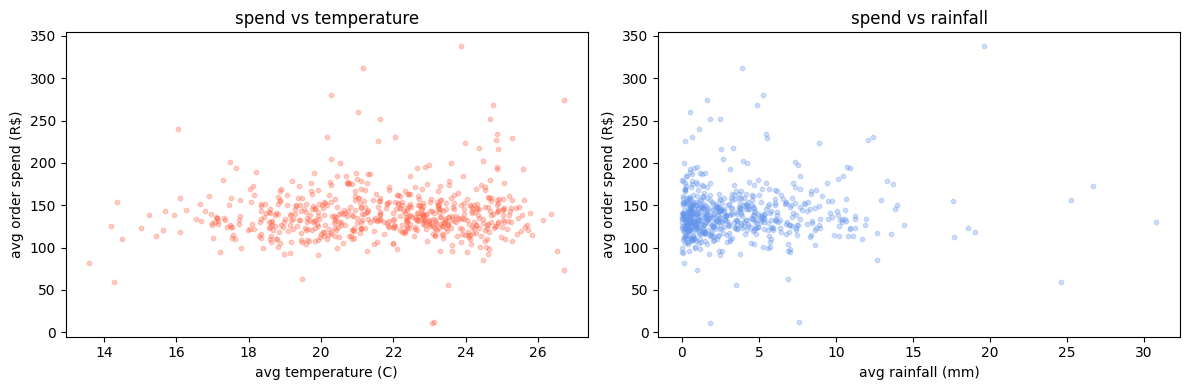

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(daily['avg_temp'], daily['avg_spend'], alpha=0.3, s=10, color='tomato')
axes[0].set_xlabel('avg temperature (C)')
axes[0].set_ylabel('avg order spend (R$)')
axes[0].set_title('spend vs temperature')

axes[1].scatter(daily['total_rain'], daily['avg_spend'], alpha=0.3, s=10, color='cornflowerblue')
axes[1].set_xlabel('avg rainfall (mm)')
axes[1].set_ylabel('avg order spend (R$)')
axes[1].set_title('spend vs rainfall')

plt.tight_layout()
plt.savefig('cleaned/plot_spend_vs_weather.png', dpi=100)
plt.show()

## cancellation rate by weather bucket

we split temperature and rainfall into rough buckets (low/medium/high) and see
if the cancellation rate changes across those buckets.
this is just exploratory - the actual statistical test comes in the next notebook.

/var/folders/b_/mk352lds10x85889s_h64kgh0000gn/T/ipykernel_41902/213661005.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancel_by_temp = df.groupby('temp_bucket')['is_returned'].mean() * 100


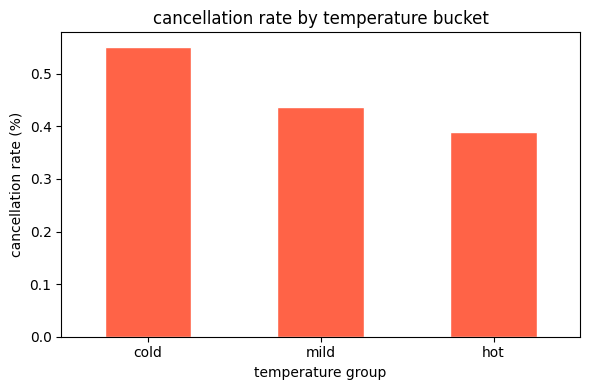

temp_bucket
cold    0.551290
mild    0.436341
hot     0.389250
Name: is_returned, dtype: float64


In [10]:
# split temperature into 3 equal-sized groups using pandas qcut
# qcut splits by quantile so each bucket has roughly the same number of orders
df['temp_bucket'] = pd.qcut(df['temp_mean_c'], q=3, labels=['cold', 'mild', 'hot'])

cancel_by_temp = df.groupby('temp_bucket')['is_returned'].mean() * 100

plt.figure(figsize=(6, 4))
cancel_by_temp.plot(kind='bar', color='tomato', edgecolor='white')
plt.title('cancellation rate by temperature bucket')
plt.ylabel('cancellation rate (%)')
plt.xlabel('temperature group')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('cleaned/plot_cancel_by_temp.png', dpi=100)
plt.show()

print(cancel_by_temp)

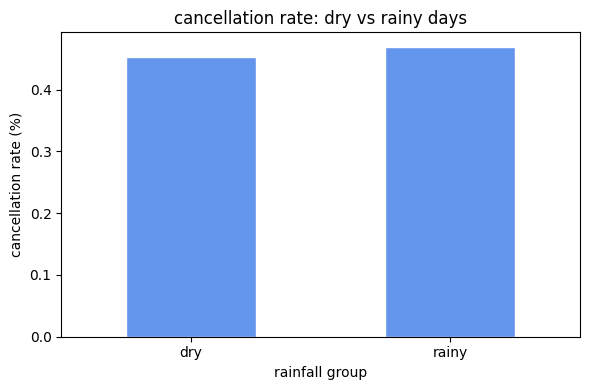

rain_bucket
dry      0.452061
rainy    0.469195
Name: is_returned, dtype: float64

dry days: 52869 | rainy days: 35806


In [11]:
# rainfall has loads of zero values so splitting into 3 equal groups doesnt work well
# instead just split into dry (0mm) vs rainy (>0mm) which makes more logical sense anyway
df['rain_bucket'] = df['precip_total_mm'].apply(lambda x: 'rainy' if x > 0 else 'dry')

cancel_by_rain = df.groupby('rain_bucket')['is_returned'].mean() * 100

plt.figure(figsize=(6, 4))
cancel_by_rain.plot(kind='bar', color='cornflowerblue', edgecolor='white')
plt.title('cancellation rate: dry vs rainy days')
plt.ylabel('cancellation rate (%)')
plt.xlabel('rainfall group')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('cleaned/plot_cancel_by_rain.png', dpi=100)
plt.show()

print(cancel_by_rain)
print()
print('dry days:', (df['rain_bucket'] == 'dry').sum(), '| rainy days:', (df['rain_bucket'] == 'rainy').sum())

## top product categories

just a quick look at what categories are most common
might be useful later if we want to see if weather affects specific types of shopping

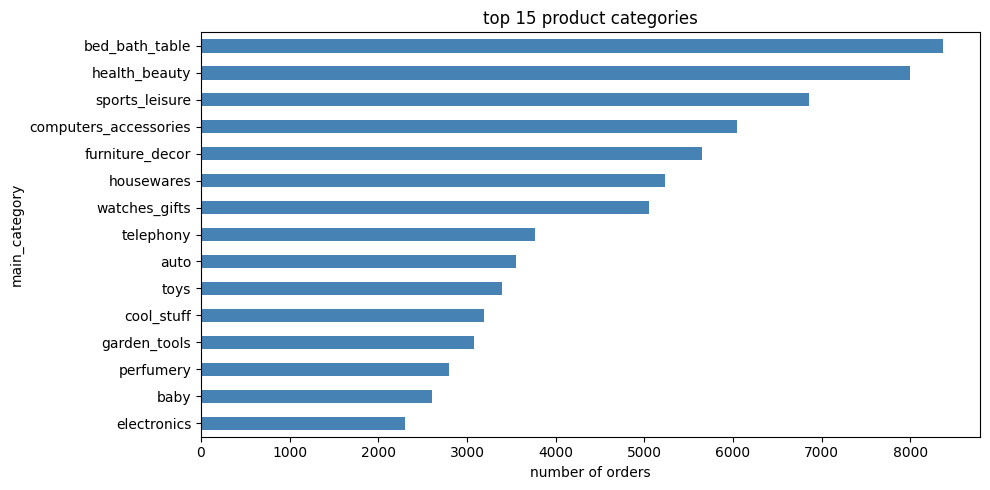

In [12]:
top_cats = df['main_category'].value_counts().head(15)

plt.figure(figsize=(10, 5))
top_cats.plot(kind='barh', color='steelblue')
plt.title('top 15 product categories')
plt.xlabel('number of orders')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('cleaned/plot_top_categories.png', dpi=100)
plt.show()

## correlation summary
 1 = perfect positive relationship, -1 = perfect negative, 0 = no relationship.


In [13]:
# use the daily aggregated table for this
corr_cols = ['order_count', 'avg_spend', 'avg_temp', 'total_rain', 'avg_humidity']
corr = daily[corr_cols].corr()

# just show correlations with order_count and avg_spend
print('correlations with order count and avg spend:')
print(corr[['order_count', 'avg_spend']].round(3))

correlations with order count and avg spend:
              order_count  avg_spend
order_count         1.000     -0.080
avg_spend          -0.080      1.000
avg_temp           -0.063      0.084
total_rain         -0.066      0.060
avg_humidity        0.054     -0.003
